# LeNet

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Convolution2D, MaxPool2D, MaxPooling2D, Dropout, Conv2D, Flatten, Dense, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import os
import glob

In [3]:
train_datagen=ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
training_set=train_datagen.flow_from_directory('datasets/train',target_size=(256,256),batch_size=32,class_mode='categorical')

Found 1545 images belonging to 4 classes.


In [4]:
test_datagen=ImageDataGenerator(rescale=1./255)
test_set=test_datagen.flow_from_directory('datasets/test',target_size=(256,256),batch_size=32,class_mode='categorical')

Found 381 images belonging to 4 classes.


In [5]:
Classifier=Sequential()
Classifier.add(Convolution2D(32,3,3,input_shape=(256,256,3),activation='relu'))
Classifier.add(MaxPooling2D(pool_size=(2,2)))
Classifier.add(Convolution2D(128,3,3,activation='relu'))
Classifier.add(MaxPooling2D(pool_size=(2,2)))
Classifier.add(Flatten())
Classifier.add(Dense(256, activation='relu'))
Classifier.add(Dense(4, activation='softmax'))

Classifier.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
Classifier.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 85, 85, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 42, 42, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 128)       36992     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 128)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 6272)              0         
                                                                 
 dense (Dense)               (None, 256)               1

In [6]:
model_path = "LeNet.h5"

callbacks = [
    ModelCheckpoint(model_path, monitor='accuracy', verbose=1, save_best_only=True)
]

In [7]:
epochs = 200
batch_size = 32

In [8]:
#### Fitting the model
history = Classifier.fit(
           training_set, steps_per_epoch=training_set.samples // batch_size, 
           epochs=epochs, 
           validation_data=test_set,validation_steps=test_set.samples // batch_size,
           callbacks=callbacks)

Epoch 1/200
48/48 [==============================] - ETA: 0s - loss: 1.3898 - accuracy: 0.3126
Epoch 1: accuracy improved from -inf to 0.31262, saving model to LeNet.h5
48/48 [==============================] - 24s 493ms/step - loss: 1.3898 - accuracy: 0.3126 - val_loss: 1.3934 - val_accuracy: 0.2330
Epoch 2/200
48/48 [==============================] - ETA: 0s - loss: 1.3766 - accuracy: 0.3206
Epoch 2: accuracy improved from 0.31262 to 0.32056, saving model to LeNet.h5
48/48 [==============================] - 23s 478ms/step - loss: 1.3766 - accuracy: 0.3206 - val_loss: 1.3895 - val_accuracy: 0.2330
Epoch 3/200
48/48 [==============================] - ETA: 0s - loss: 1.3774 - accuracy: 0.3159
Epoch 3: accuracy did not improve from 0.32056
48/48 [==============================] - 23s 480ms/step - loss: 1.3774 - accuracy: 0.3159 - val_loss: 1.3923 - val_accuracy: 0.2273
Epoch 4/200
48/48 [==============================] - ETA: 0s - loss: 1.3777 - accuracy: 0.3206
Epoch 4: accuracy did not 

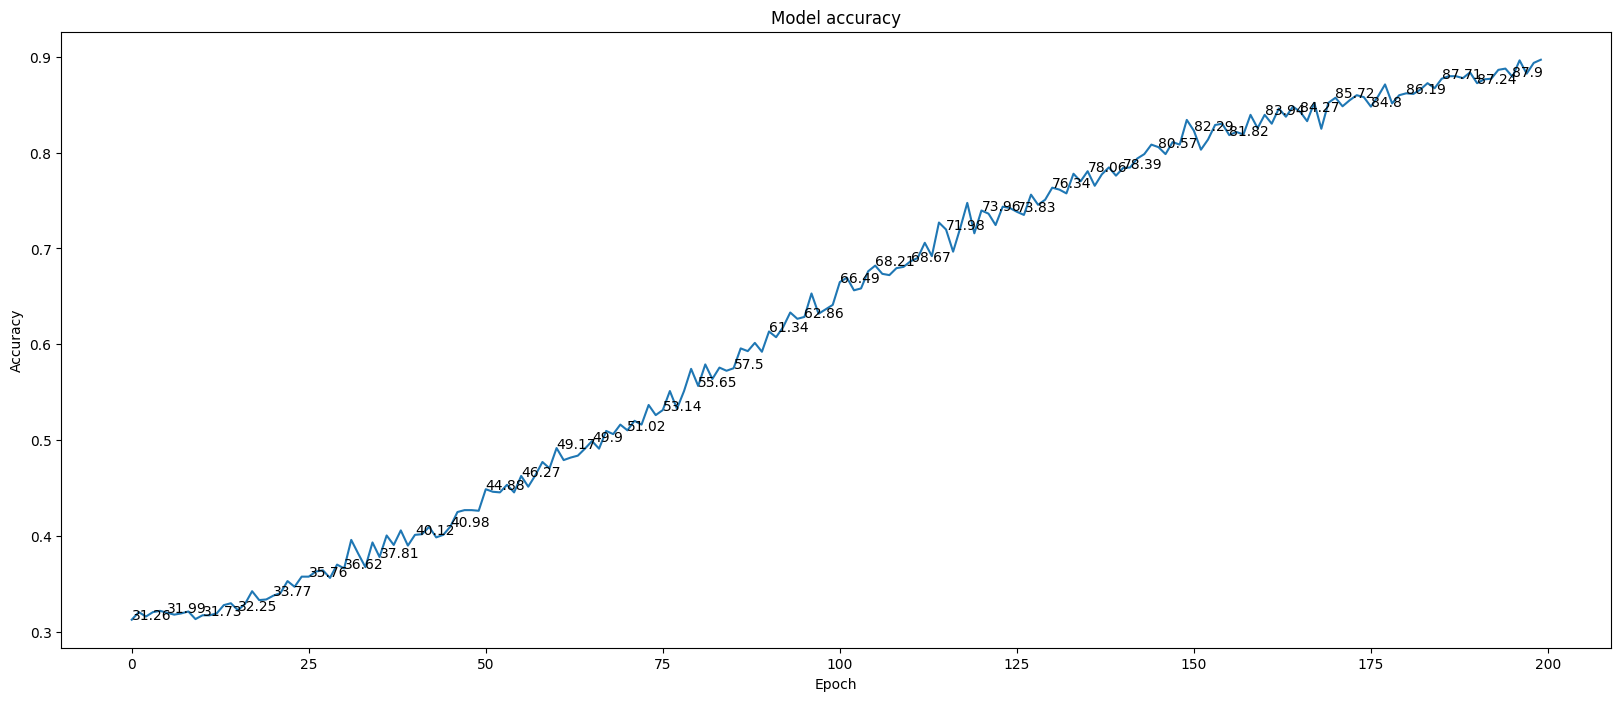

In [9]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['accuracy'])

for i in range(epochs):
    if i%5 == 0:
        plt.annotate(np.round(history.history['accuracy'][i]*100,2),xy=(i,history.history['accuracy'][i]))

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()

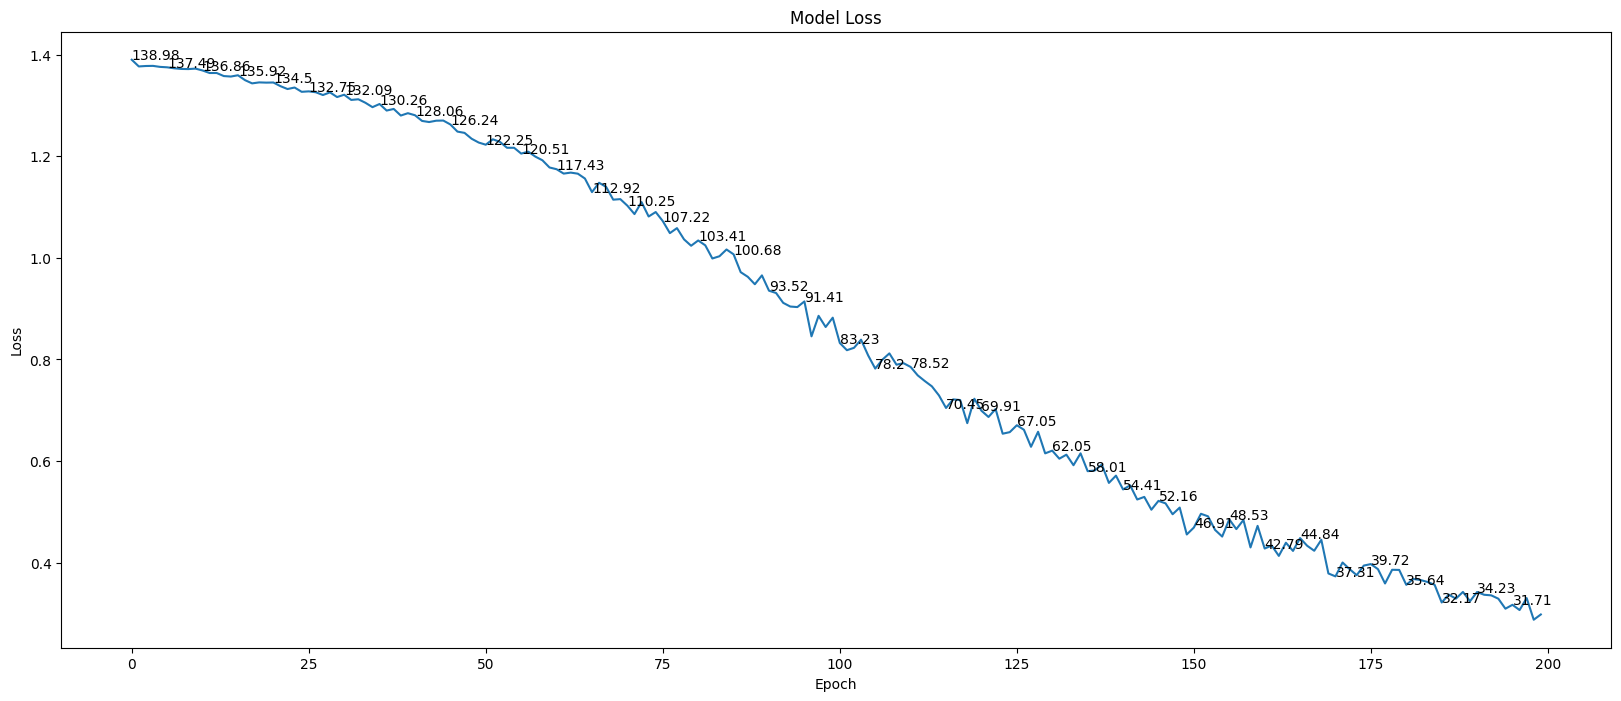

In [10]:
plt.figure(figsize=(20, 8))
plt.plot(history.history['loss'])

for i in range(epochs):
    if i%5 == 0:
        plt.annotate(np.round(history.history['loss'][i]*100,2),xy=(i,history.history['loss'][i]))

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [11]:
import h5py
Classifier.save('Lenet.h5')